In [11]:
### Testing Normality of Correlations - ATOC7500 Lecture #4
### coded by Prof Libby Barnes (CSU) with additional updates/coding by Prof. Jennifer Kay (CU)
### last updated September 14, 2020
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
print('finished...')

finished...


In [24]:
### Create a time series of random variables drawn from a specified distribution
# length of true population time series
total_length = 100000

## tinker recommendation: try the different distributions and see how they influence your results.

# create normal distributions
xf = np.random.normal(0.,1.,size=total_length)
yf = np.random.normal(0.,1.,size=total_length)
# create lognormal distributions
#xf = np.random.lognormal(0.,1.,size=total_length)
#yf = np.random.lognormal(0.,1.,size=total_length)
# create uniform distributions
#xf = np.random.uniform(-1.,1.,size = total_length)
#yf = np.random.uniform(-1.,1.,size = total_length)

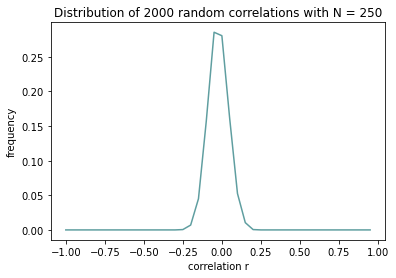

In [29]:
## Generate 2000 realizations of r (correlation) and tr (fisher-Z t-value)
## by sampling from the population time series with sample size = N
N = 250
N_r = 2000
r = np.empty((N_r,)) 
for iloop, val in enumerate(r):
    irandval_x = np.random.randint(low = 0, high = len(xf), size = N) # 250 large
    irandval_y = np.random.randint(low = 0, high = len(yf), size = N) # 250 large
    r[iloop] = stats.pearsonr(xf[irandval_x],yf[irandval_y])[0]

## Plot distribution of correlations
xinc = np.arange(-1.,1.05,0.05)
hx = np.histogram(r,xinc)
plt.plot(hx[1][:-1],hx[0]/float(np.size(r)),'-',color='cadetblue')
plt.xlabel('correlation r')
plt.ylabel('frequency')
plt.title(f'Distribution of {N_r} random correlations with N = ' + str(N))

## Calculate the Fisher-Z t-value
tr = (r * np.sqrt(N-2))/(np.sqrt(1-r**2))    ## fisher-Z t-score (Barnes Equation 44)

In [30]:
## Assess the frequency of occurrence of statistically significant correlation
## Use 95% confidence interval

## Compare the Fisher-z frequency ("Actual") with the Normal Distribution
j = np.where(tr>=stats.t.ppf(0.975,N-2)) # get t_critical the same way
a = np.size(j)/float(np.size(tr))
foo=str(np.round(a*100,3))
print('Normal Distribution Approximation = 2.5%, Actual using FisherZ = ' + foo + '%')

Normal Distribution Approximation = 2.5%, Actual using FisherZ = 2.5%


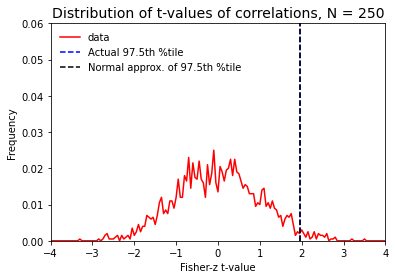

In [31]:
### Plot distribution of t-values of correlations
xinc= np.arange(-5.,5.,0.05)
hx = np.histogram(tr,xinc)
plt.plot(hx[1][:-1],hx[0]/float(np.size(tr)),'-',color='red', label = 'data')
plt.plot(np.ones((2,1))*np.percentile(tr,97.5),[0.0, 0.1],'--b', label = 'Actual 97.5th %tile')
plt.plot(np.ones((2,1))*stats.t.ppf(0.975,N-2),[0.0, 0.1],'--k', label = 'Normal approx. of 97.5th %tile')
plt.xlabel('Fisher-z t-value')
plt.ylabel('Frequency')
plt.xlim(-4,4)
plt.ylim(0.0,0.06);
plt.title('Distribution of t-values of correlations, N = ' + str(N), fontsize = 14);
plt.legend(loc = 'upper left', frameon = 0, fontsize = 10);